# Levine et al. (2015) -- Mass Cytometry of Human Bone Marrow (32-dim)

**Source:** Levine et al., "Data-Driven Phenotypic Dissection of AML Reveals Progenitor-like Cells that Correlate with Prognosis." *Cell* 162.1 (2015): 184--197.

265,627 human bone marrow cells profiled by mass cytometry (CyTOF) across 32 protein markers, with 14 manually gated cell populations (39% of cells labeled = 104,184 cells). CyTOF data features heavy-tailed protein expression distributions and overlapping cell populations with varying densities -- properties known to challenge classical distance-based validation indices (Silhouette, Davies--Bouldin, Calinski--Harabasz).

Available via the HDCytoData Bioconductor package (Weber & Robinson, 2016).

---

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [ ]:
import multiprocessing
import os, random

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

from carve import CARVE
from carve.cluster import SpectralClusteringCARVE

from case_study_plotting import (
    plot_dim_red, 
    baseline_metrics_over_k, 
    build_baseline_best_labels, 
    plot_composite_figure_ari
)

In [3]:
# --- Configuration ---
SUBSAMPLE = True
subsample_size = 5000
RANDOM_SEED = 42
K = 17

# CARVE selection criteria
MEASURE = "s"   # stability
RULE = "1se"
NOT_TWO = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

def get_n_jobs():
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4
    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Load & Preprocess Data

Load from the HDCytoData R package via rpy2. Filter to labeled cells and type markers, apply arcsinh transform (CyTOF standard, cofactor=5) and robust scaling.

In [5]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

ro.r(r"""
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("HDCytoData", quietly=TRUE)) BiocManager::install("HDCytoData")
library(HDCytoData)
library(SummarizedExperiment)
""")

ro.r("sce <- Levine_32dim_SE()")

X_all = np.array(ro.r("assay(sce)"), dtype=float)
row_df = pandas2ri.rpy2py(ro.r("as.data.frame(rowData(sce))"))
col_df = pandas2ri.rpy2py(ro.r("as.data.frame(colData(sce))"))

print(f"Full dataset: {X_all.shape[0]:,} cells x {X_all.shape[1]} markers")
print(f"Populations: {row_df['population_id'].nunique()} unique")
print(f"Labeled cells: {(row_df['population_id'] != 'unassigned').sum():,} / {X_all.shape[0]:,}")

R callback write-console: Loading required package: ExperimentHub
  
R callback write-console: Loading required package: BiocGenerics
  
R callback write-console: Loading required package: generics
  
R callback write-console: 
Attaching package: ‘generics’

  
R callback write-console: The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union

  
R callback write-console: 
Attaching package: ‘BiocGenerics’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

  
R callback write-console: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames,

Full dataset: 265,627 cells x 39 markers
Populations: 15 unique
Labeled cells: 265,627 / 265,627


In [6]:
# Filter to labeled cells only
labeled_mask = (row_df["population_id"] != "unassigned").to_numpy()
X_labeled = X_all[labeled_mask]
y_labeled = row_df["population_id"].to_numpy()[labeled_mask]

# Filter to type markers (marker_class == 2)
keep_markers = (col_df["marker_class"].astype(int) == 2).to_numpy()
X_labeled = X_labeled[:, keep_markers]
marker_names = col_df.index[keep_markers].tolist()

print(f"Labeled cells: {X_labeled.shape[0]:,} x {X_labeled.shape[1]} markers")
print(f"Populations: {len(np.unique(y_labeled))}")
print()
print("Population distribution:")
print(pd.Series(y_labeled).value_counts().to_string())

Labeled cells: 265,627 x 32 markers
Populations: 15

Population distribution:
15    161443
7      26366
10     21099
8      20108
9      16520
13      6135
2       3905
4       3295
3       2248
11      1238
1       1207
6        916
14       513
12       330
5        304


In [7]:
# Arcsinh transform (CyTOF standard) + robust scaling
cofactor = 5.0
X_transformed = np.arcsinh(X_labeled.astype(np.float64) / cofactor)
X_scaled = RobustScaler(quantile_range=(10, 90)).fit_transform(X_transformed)

In [8]:
# Remove population 15 from the labeled dataset
keep_mask = y_labeled != 15

y_labeled = y_labeled[keep_mask]
X_labeled = X_labeled[keep_mask]
X_transformed = X_transformed[keep_mask]
X_scaled = X_scaled[keep_mask]

print(f"After removing population 15: {X_scaled.shape[0]:,} cells x {X_scaled.shape[1]} markers")
print("Remaining populations:", np.unique(y_labeled))

After removing population 15: 104,184 cells x 32 markers
Remaining populations: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


---

## 2. Subsampling & Visualization

In [9]:
X = X_scaled
y = pd.Series(y_labeled, name="population_id")

if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)
    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]
    X = X[idx]
    y = y.loc[selected_idx]
    print(f"Subsampled to {X.shape[0]:,} cells ({frac:.0%})")

print(f"Final: {X.shape[0]:,} cells x {X.shape[1]} markers, {y.nunique()} populations")

Subsampled to 5,000 cells (5%)
Final: 5,000 cells x 32 markers, 14 populations


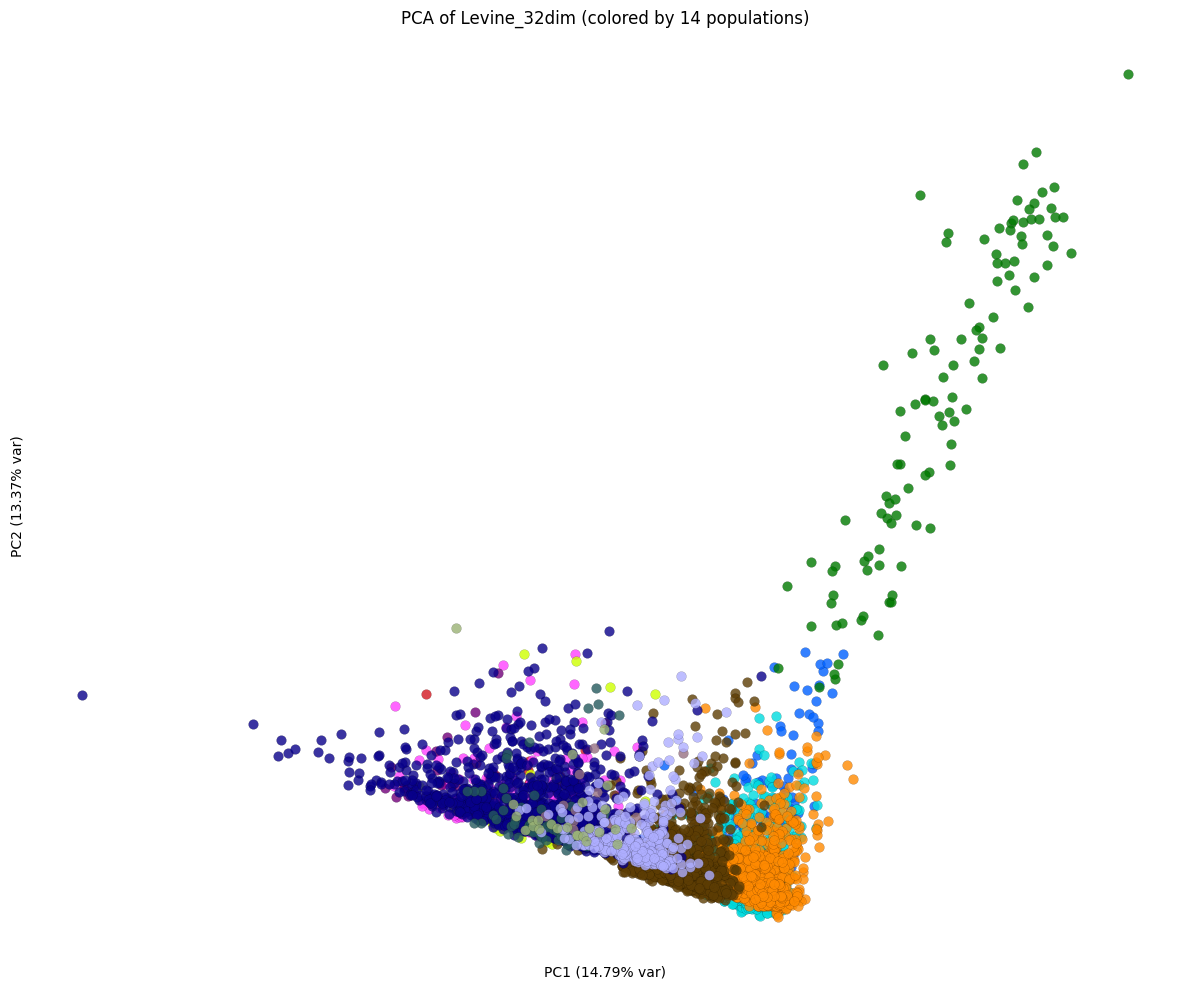

In [10]:
plot_dim_red(
    X=X, y=y, method="pca", show_legend=False,
    title="PCA of Levine_32dim (colored by 14 populations)"
)

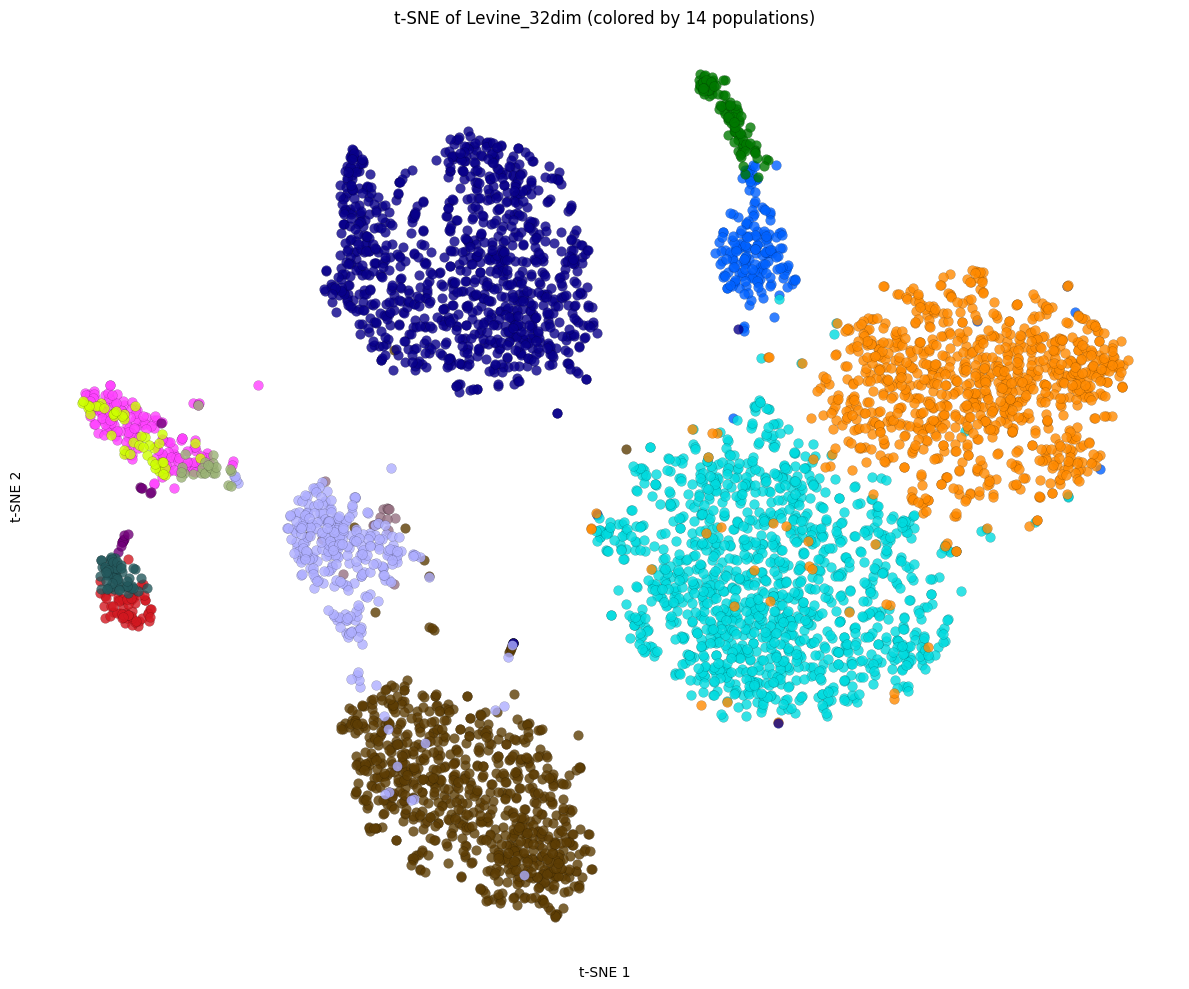

In [11]:
plot_dim_red(
    X=X, y=y, method="tsne", show_legend=False,
    title="t-SNE of Levine_32dim (colored by 14 populations)"
)

---

## 3. Baseline Metrics

We evaluate Silhouette, Gap statistic, Davies-Bouldin, and Calinski-Harabasz across k = 2, ..., 30 for KMeans and Agglomerative clustering (ward and single linkage):

In [12]:
ks = list(range(7, K + 1))

model_grids = [
    (KMeans, {"n_clusters": ks}),
    # (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    # (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "single"]}),
    (SpectralClusteringCARVE, {"n_clusters": ks, "affinity": ["self_tuning"]})
]


baseline selections (max metric):
  - Silhouette: k=7, score=0.2410, ari=0.6232   [KMeans]
  - Gap Statistic: k=15, score=2.5642, ari=0.4900   [SpectralCARVE (affinity=self_tuning)]
  - DB: k=7, score=0.4323, ari=0.6232   [KMeans]
  - CH: k=7, score=751.0069, ari=0.6232   [KMeans]


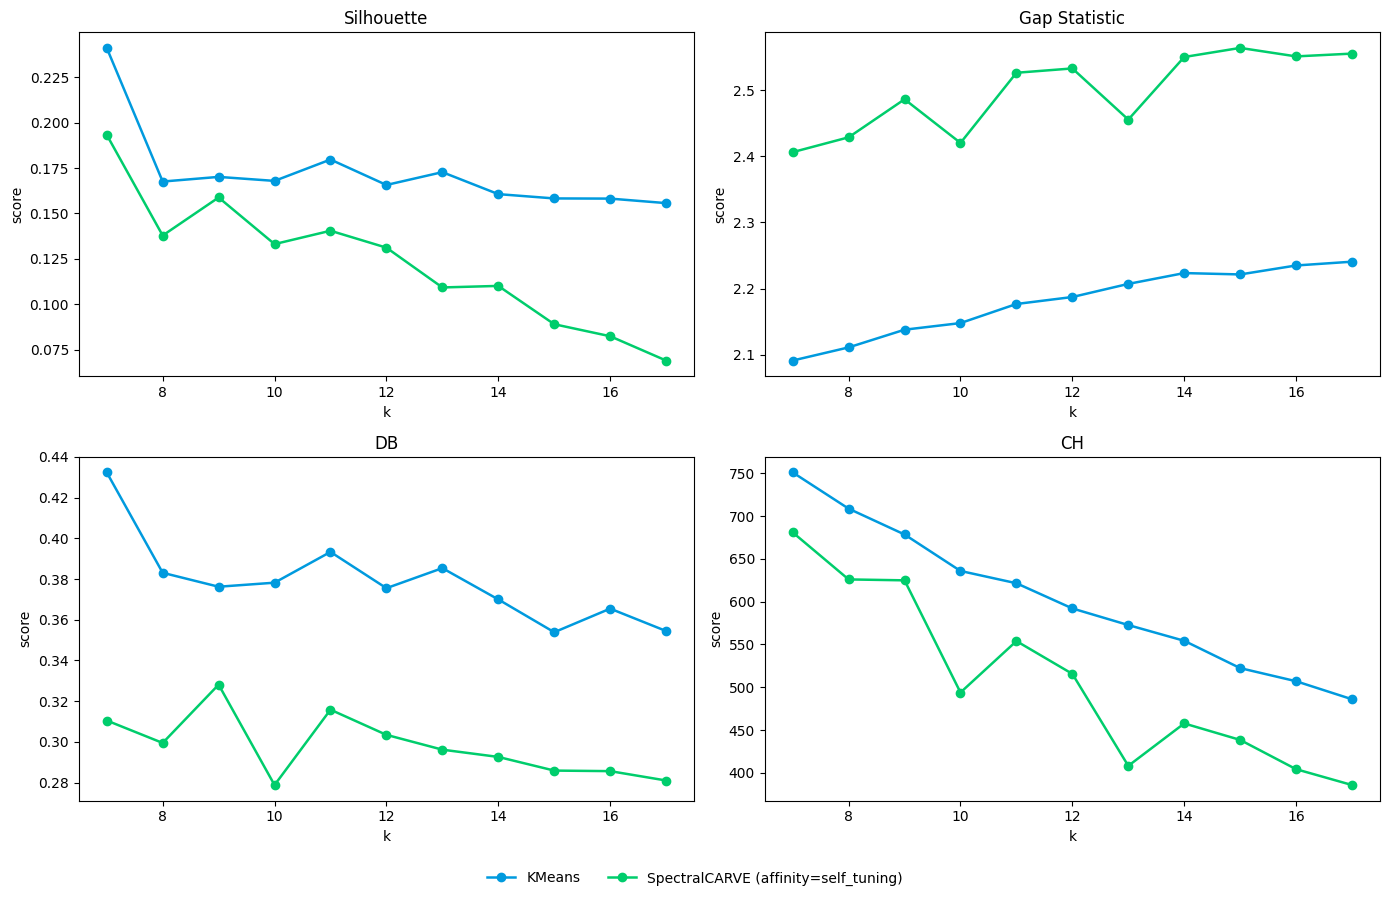

In [13]:
curves_df, best_df = baseline_metrics_over_k(
    X, y=y, model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    n_jobs=N_JOBS, random_state=RANDOM_SEED, ncols=2, figsize=(14, 9),
)

In [14]:
print("Best k selected by each metric:")
print(best_df[["metric", "best_model", "best_k", "best_ari"]].to_string(index=False))

Best k selected by each metric:
    metric                           best_model  best_k  best_ari
silhouette                               KMeans       7  0.623232
       gap SpectralCARVE (affinity=self_tuning)      15  0.490009
        DB                               KMeans       7  0.623232
        CH                               KMeans       7  0.623232


---

## 4. CARVE Analysis

In [23]:
carve_path = Path("./carve_state_saves/carve_levine32.carve")

if not carve_path.is_file():
    carve = CARVE(
        estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
    )
    carve.fit(X, reference_labels=y)

    # Save fitted state to avoid re-running
    carve_path.parent.mkdir(parents=True, exist_ok=True)
    carve.save(str(carve_path))
    print(f"Saved CARVE state to {carve_path}")
else:
    print(f"Loading CARVE state from {carve_path}")
    carve = CARVE.load(str(carve_path))
    carve.X_ = X

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 5000
[CARVE] n_features         : 32
[CARVE] n_clusters         : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 22
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...



python(93826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93830) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93831) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93832) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93833) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93834) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93835) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [1/22] est=KMeans n_clusters=7 | ARI_stab=0.760±0.016  ARI_gen=0.737±0.014  
[CARVE] [2/22] est=KMeans n_clusters=8 | ARI_stab=0.844±0.013  ARI_gen=0.779±0.013  
[CARVE] [3/22] est=KMeans n_clusters=9 | ARI_stab=0.848±0.011  ARI_gen=0.810±0.010  
[CARVE] [4/22] est=KMeans n_clusters=10 | ARI_stab=0.845±0.011  ARI_gen=0.818±0.007  
[CARVE] [5/22] est=KMeans n_clusters=11 | ARI_stab=0.847±0.009  ARI_gen=0.806±0.008  
[CARVE] [6/22] est=KMeans n_clusters=12 | ARI_stab=0.829±0.009  ARI_gen=0.776±0.008  
[CARVE] [7/22] est=KMeans n_clusters=13 | ARI_stab=0.815±0.009  ARI_gen=0.749±0.008  
[CARVE] [8/22] est=KMeans n_clusters=14 | ARI_stab=0.799±0.008  ARI_gen=0.738±0.008  
[CARVE] [9/22] est=KMeans n_clusters=15 | ARI_stab=0.789±0.008  ARI_gen=0.719±0.008  
[CARVE] [10/22] est=KMeans n_clusters=16 | ARI_stab=0.765±0.008  ARI_gen=0.693±0.008  
[CARVE] [11/22] est=KMeans n_clusters=17 | ARI_stab=0.750±0.008  ARI_gen=0.666±0.007  


/Users/kaiwycik/GitHub/ClusteringValidation/code/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
python(94001) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94003) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94005) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94007) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94009) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94011) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94013) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94015) MallocSt

[CARVE] [12/22] est=SpectralClusteringCARVE n_clusters=7 | ARI_stab=0.859±0.011  ARI_gen=0.643±0.007  


...

[CARVE] [14/22] est=SpectralClusteringCARVE n_clusters=9 | ARI_stab=0.888±0.007  ARI_gen=0.738±0.006  


python(94166) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94167) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [15/22] est=SpectralClusteringCARVE n_clusters=10 | ARI_stab=0.887±0.007  ARI_gen=0.684±0.007  


python(94207) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94218) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [16/22] est=SpectralClusteringCARVE n_clusters=11 | ARI_stab=0.801±0.007  ARI_gen=0.645±0.005  
[CARVE] [17/22] est=SpectralClusteringCARVE n_clusters=12 | ARI_stab=0.798±0.008  ARI_gen=0.605±0.005  
[CARVE] [18/22] est=SpectralClusteringCARVE n_clusters=13 | ARI_stab=0.779±0.007  ARI_gen=0.577±0.005  
[CARVE] [19/22] est=SpectralClusteringCARVE n_clusters=14 | ARI_stab=0.784±0.008  ARI_gen=0.553±0.004  
[CARVE] [20/22] est=SpectralClusteringCARVE n_clusters=15 | ARI_stab=0.765±0.007  ARI_gen=0.557±0.004  
[CARVE] [21/22] est=SpectralClusteringCARVE n_clusters=16 | ARI_stab=0.768±0.006  ARI_gen=0.572±0.004  
[CARVE] [22/22] est=SpectralClusteringCARVE n_clusters=17 | ARI_stab=0.775±0.006  ARI_gen=0.572±0.003  

[CARVE] finished. evaluated 22 estimator configurations.
Saved CARVE state to carve_state_saves/carve_levine32.carve


/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:278: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


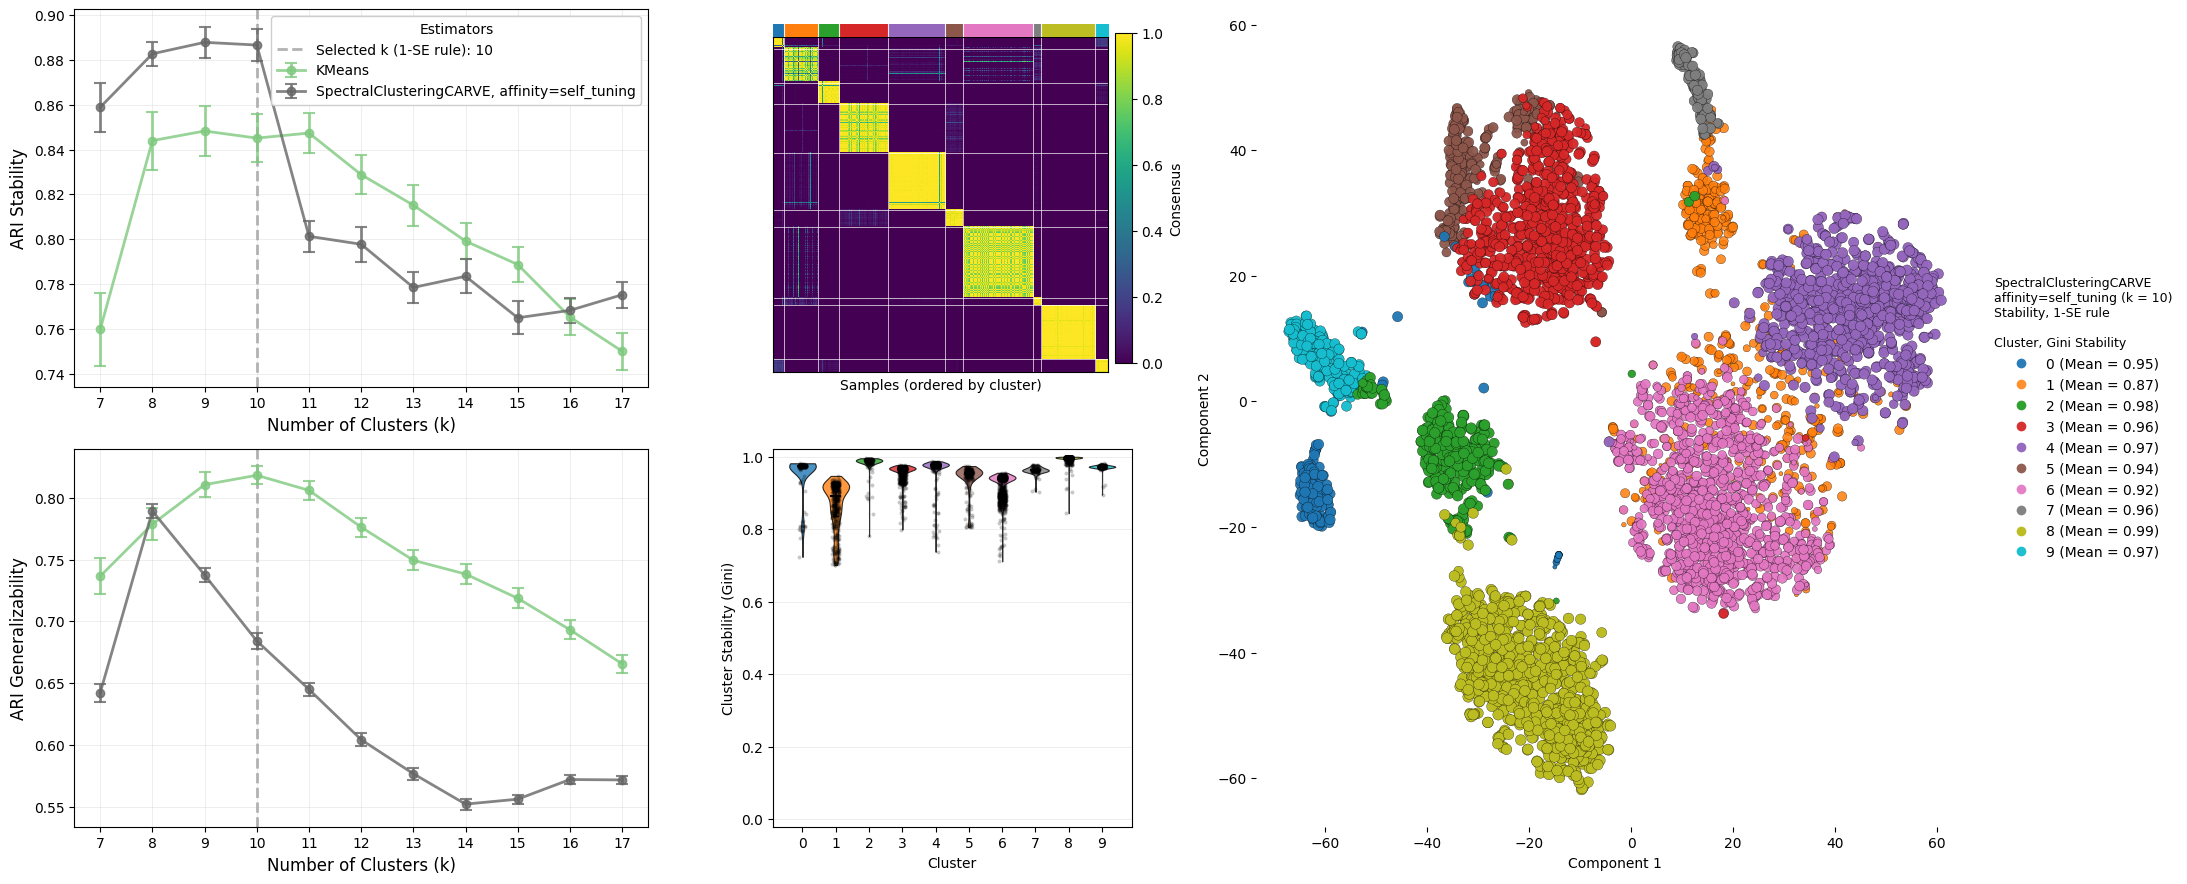

In [36]:
if "tsne_embedding" not in globals():
    tsne_embedding = TSNE(random_state=RANDOM_SEED).fit_transform(X)

fig = plt.figure(figsize=(22, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1.6, 1.0, 2.0])
ax_l1 = fig.add_subplot(gs[0, 0])
ax_l2 = fig.add_subplot(gs[1, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_m2 = fig.add_subplot(gs[1, 1])
ax_r = fig.add_subplot(gs[:, 2])

carve.plot_metric_over_n_clusters(measure='stability', rule=RULE, not_two=NOT_TWO, ax=ax_l1)
carve.plot_metric_over_n_clusters(measure='generalizability', rule=RULE, not_two=NOT_TWO, ax=ax_l2, legend=False)

carve.plot_consensus_matrix(measure='stability', rule=RULE, not_two=NOT_TWO, ax=ax_m1, palette='tab10')
carve.plot_cluster_violin(measure='stability', rule=RULE, not_two=NOT_TWO, ax=ax_m2, annotation=False, palette='tab10')

carve.plot_cluster_scatter(
    measure='stability', rule=RULE, not_two=NOT_TWO,
    embedding=tsne_embedding, ax=ax_r, palette='tab10'
)

plt.show()

In [26]:
print(
      f"CARVE selects k={carve.get_k(measure=MEASURE, rule=RULE, not_two=NOT_TWO)} "
      f"(measure={MEASURE}, rule={RULE}, not_two={NOT_TWO})"
)

CARVE selects k=10 (measure=s, rule=1se, not_two=True)


---

## 5. Quantitative Comparison

### 5.1 Composite Paper Figure (with ARI Comparison)

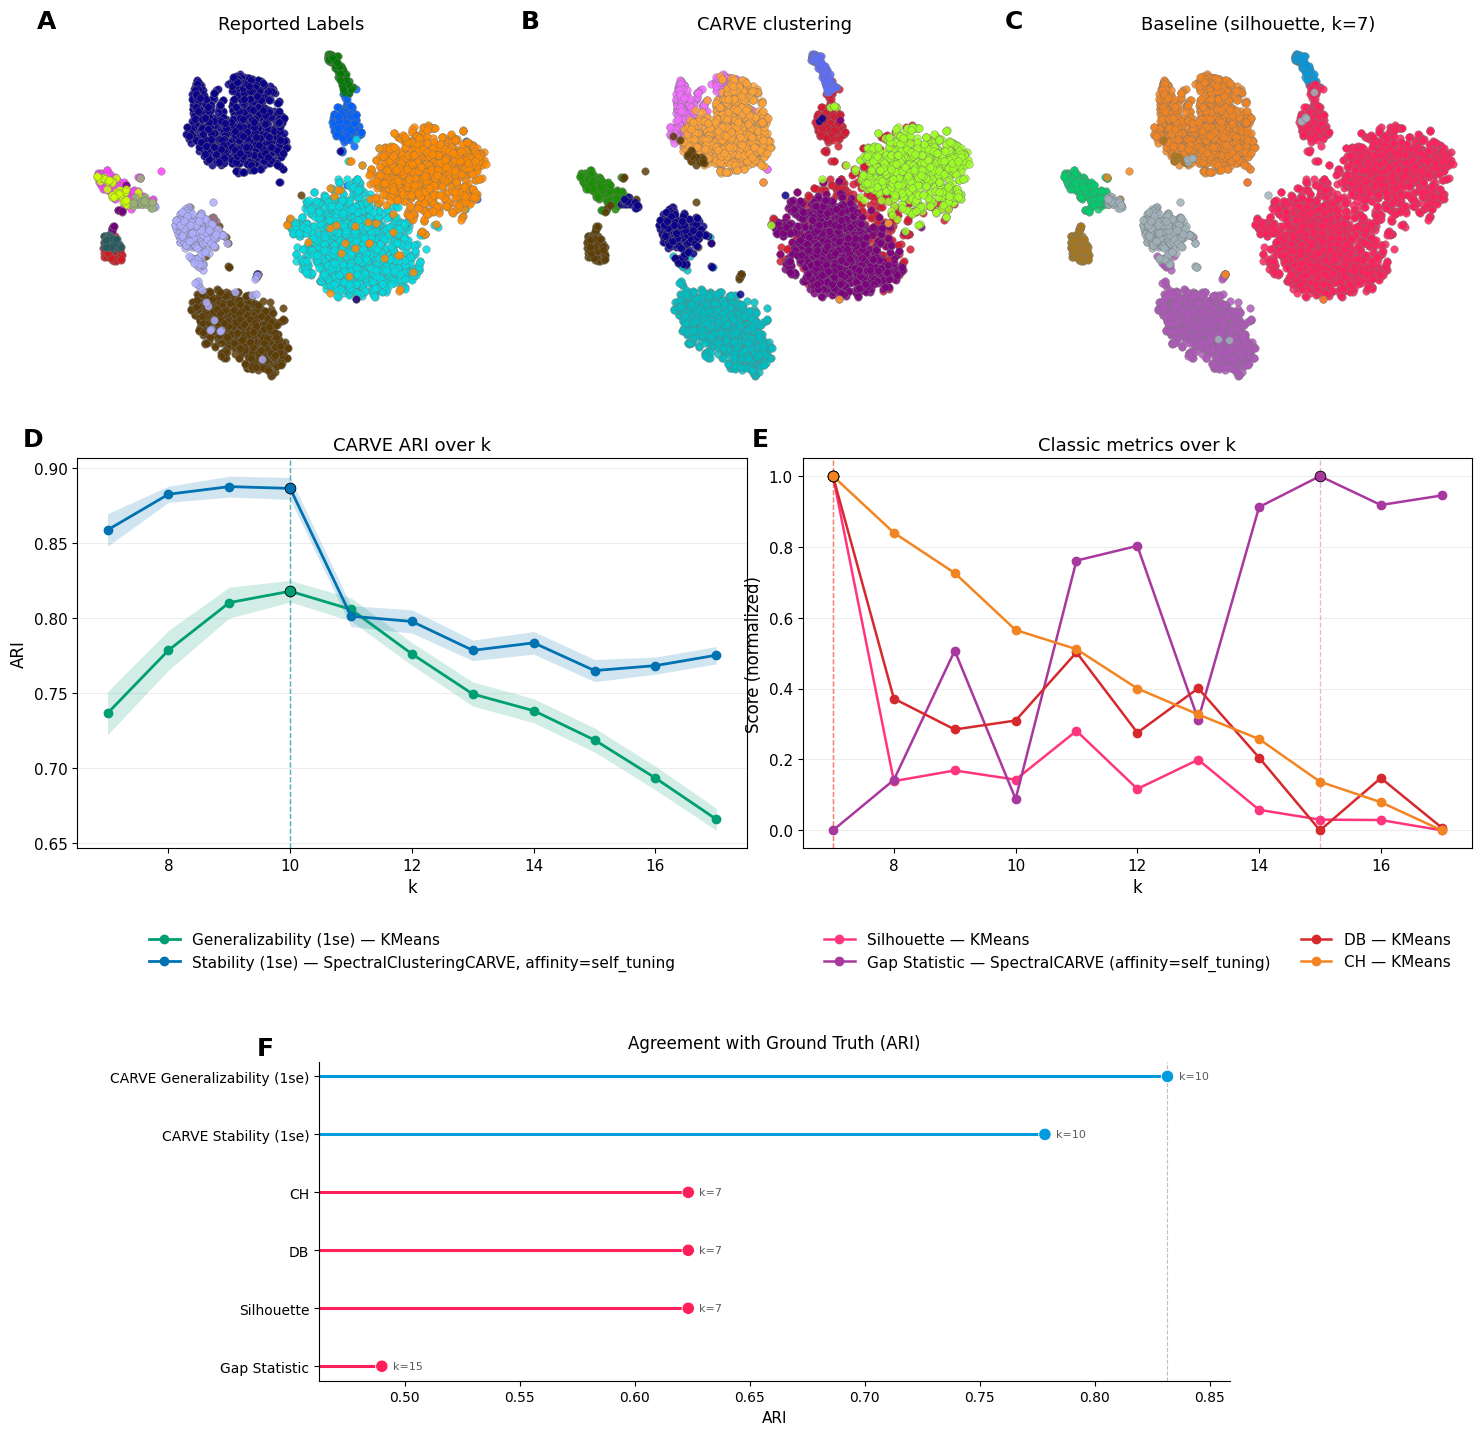

Baseline model used: KMeans (k=7)


In [ ]:
# Choose baseline metric for panel C and alluvial right column
# options: "silhouette", "gap", "DB", "CH"
baseline_metric = "silhouette"

baseline_labels, baseline_model, baseline_k = build_baseline_best_labels(
    X=X,
    best_df=best_df,
    model_grids=model_grids,
    metric=baseline_metric,
    random_state=RANDOM_SEED,
)

# Map shorthand to names expected by plot_composite_figure
measure_map = {"s": "stability", "g": "generalizability"}
measure_for_plot = measure_map.get(MEASURE, MEASURE)

fig = plot_composite_figure_ari(
    X=X,
    y=y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y),
    carve_obj=carve,
    curves_df=curves_df,
    best_df=best_df,
    silhouette_labels=baseline_labels,
    embedding=tsne_embedding,
    measure=measure_for_plot,
    rule=RULE,
    not_two=NOT_TWO,
    consensus_type="stability",
    baseline_title=f"Baseline ({baseline_metric}, k={baseline_k})",
    figsize=(18, 16),
)

plt.show()
print(f"Baseline model used: {baseline_model} (k={baseline_k})")

---

## 6. Summary

Levine_32dim is a canonical CyTOF benchmark with 14 manually gated bone marrow populations. The heavy-tailed protein expression distributions, overlapping populations, and varying population sizes challenge classical distance-based validation indices. We compare CARVE's stability-based selection (measure=s, rule=1se, not_two=True) against four classical metrics and quantify agreement with the 14 ground-truth populations using ARI.

---